# 03 — Modelado: SARIMA

## Objetivo
Construir un modelo estadístico de series temporales para predecir las ventas 
de GROCERY I en la tienda 1.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

# Carga del dataset procesado
train = pd.read_csv('../data/processed/train_features.csv')
train['date'] = pd.to_datetime(train['date'])

# Filtrar GROCERY I - Tienda 1
serie = train[(train['store_nbr'] == 1) & 
              (train['family'] == 'GROCERY I')].copy()
serie = serie.set_index('date')['sales']

print(f"Tienda: 1 | Familia: GROCERY I")
print(f"Período: {serie.index.min()} → {serie.index.max()}")
print(f"Total de días: {len(serie)}")

Tienda: 1 | Familia: GROCERY I
Período: 2013-01-01 00:00:00 → 2017-08-15 00:00:00
Total de días: 1684


## 1. Visualización de la Serie

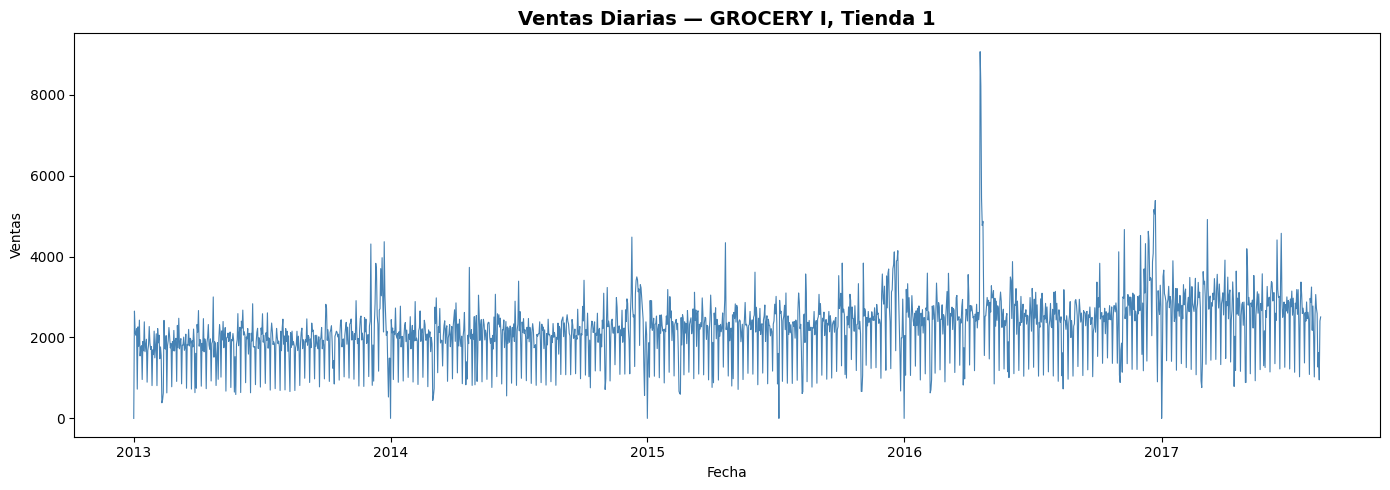

In [2]:
plt.figure(figsize=(14, 5))
plt.plot(serie, color='steelblue', linewidth=0.8)
plt.title('Ventas Diarias — GROCERY I, Tienda 1', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.tight_layout()
plt.savefig('../reports/figures/06_serie_grocery1.png', dpi=150)
plt.show()

## 2. División Train / Test

Train: 2013-01-01 00:00:00 → 2017-07-16 00:00:00 (1654 días)
Test:  2017-07-17 00:00:00 → 2017-08-15 00:00:00 (30 días)


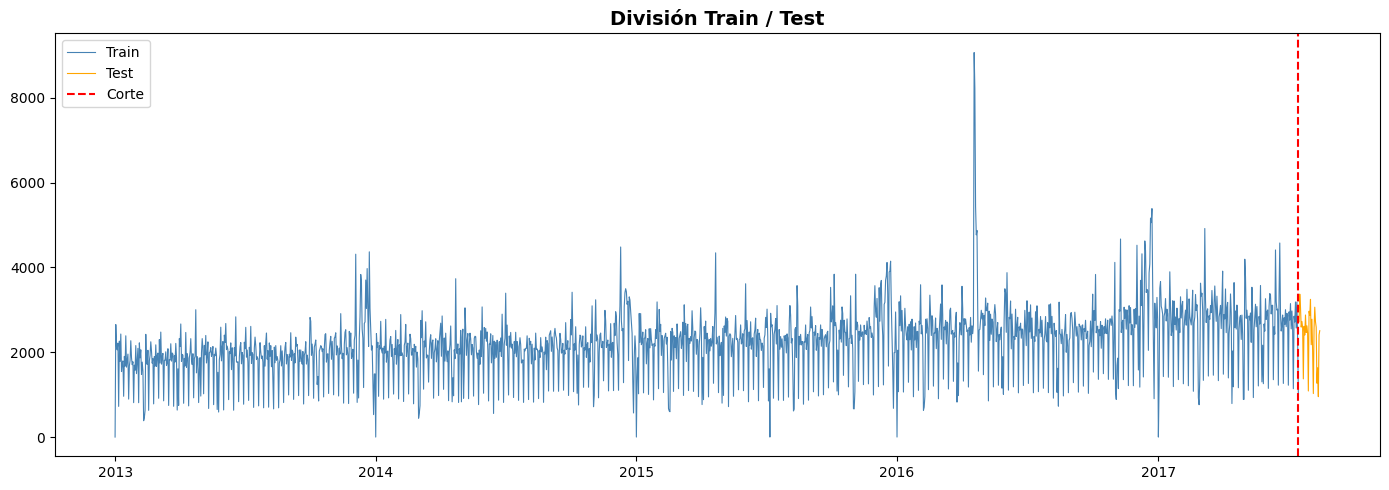

In [3]:
# División temporal: últimos 30 días para test
fecha_corte = serie.index.max() - pd.Timedelta(days=30)

train_serie = serie[serie.index <= fecha_corte]
test_serie = serie[serie.index > fecha_corte]

print(f"Train: {train_serie.index.min()} → {train_serie.index.max()} ({len(train_serie)} días)")
print(f"Test:  {test_serie.index.min()} → {test_serie.index.max()} ({len(test_serie)} días)")

# Visualización
plt.figure(figsize=(14, 5))
plt.plot(train_serie, color='steelblue', linewidth=0.8, label='Train')
plt.plot(test_serie, color='orange', linewidth=0.8, label='Test')
plt.axvline(fecha_corte, color='red', linestyle='--', label='Corte')
plt.title('División Train / Test', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/07_train_test_split.png', dpi=150)
plt.show()

## 3. Entrenamiento del Modelo SARIMA

In [4]:
# Entrenamiento SARIMA
# p=1, d=1, q=1 → componente no estacional
# P=1, D=1, Q=1, s=7 → componente estacional semanal
modelo_sarima = SARIMAX(train_serie,
                        order=(1, 1, 1),
                        seasonal_order=(1, 1, 1, 7),
                        enforce_stationarity=False,
                        enforce_invertibility=False)

resultado_sarima = modelo_sarima.fit(disp=False)

print(resultado_sarima.summary())

                                     SARIMAX Results                                     
Dep. Variable:                             sales   No. Observations:                 1654
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood              -12679.516
Date:                           Wed, 04 Mar 2026   AIC                          25369.032
Time:                                   22:38:52   BIC                          25396.035
Sample:                                        0   HQIC                         25379.048
                                          - 1654                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3935      0.021     18.779      0.000       0.352       0.435
ma.L1         -0.9989      0.011    -90.367

### 📝 Interpretación

El modelo SARIMA fue entrenado con 1654 días de ventas de GROCERY I en la tienda 1. 
Los componentes de media móvil (MA) tanto estacional como no estacional resultaron 
estadísticamente significativos (p-valor = 0.000), confirmando que el modelo captura 
correctamente los patrones temporales de la serie. Sin embargo, el componente 
autorregresivo estacional (ar.S.L7) no resultó significativo (p-valor = 0.668), 
lo que sugiere que una versión simplificada del modelo podría funcionar igual de bien 
con menos parámetros. Los valores de Kurtosis elevados (19.10) confirman la presencia 
de picos extremos en las ventas, como los feriados y promociones identificados en el EDA.

## 4. Predicción y Evaluación

=== MÉTRICAS SARIMA ===
MAE:  332.34
RMSE: 472.63
MAPE: 17.27%


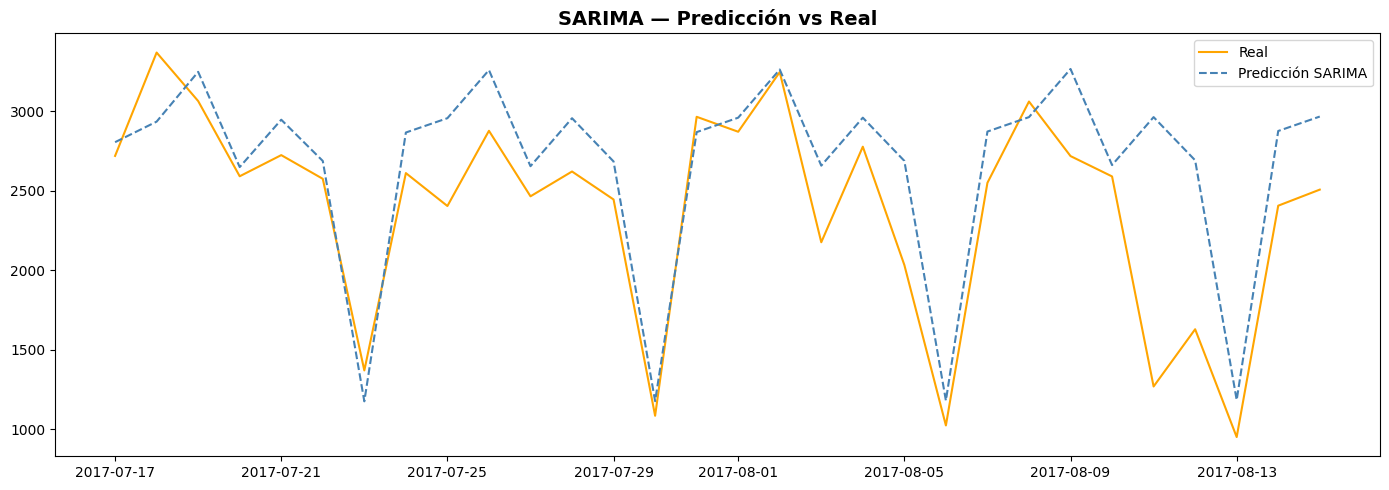

In [5]:
# Predicción sobre el período de test
predicciones = resultado_sarima.forecast(steps=len(test_serie))
predicciones.index = test_serie.index

# Métricas
def calcular_metricas(real, predicho):
    mae = np.mean(np.abs(real - predicho))
    rmse = np.sqrt(np.mean((real - predicho) ** 2))
    # MAPE evitando división por cero
    mask = real != 0
    mape = np.mean(np.abs((real[mask] - predicho[mask]) / real[mask])) * 100
    return mae, rmse, mape

mae, rmse, mape = calcular_metricas(test_serie.values, predicciones.values)

print("=== MÉTRICAS SARIMA ===")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

# Visualización
plt.figure(figsize=(14, 5))
plt.plot(test_serie, color='orange', linewidth=1.5, label='Real')
plt.plot(predicciones, color='steelblue', linewidth=1.5, 
         linestyle='--', label='Predicción SARIMA')
plt.title('SARIMA — Predicción vs Real', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/08_sarima_prediccion.png', dpi=150)
plt.show()

### 📝 Interpretación

El modelo SARIMA obtuvo un MAPE de 17.27%, lo que significa que en promedio se equivoca 
un 17% respecto al valor real de ventas. El gráfico muestra que el modelo captura 
correctamente el patrón semanal — las subidas y bajadas siguen la misma forma que 
las ventas reales. Sin embargo, el modelo tiende a sobreestimar en los días de caída 
brusca (feriados) y a subestimar en los picos más altos. Esto es esperado en SARIMA 
ya que no incorpora variables externas como feriados o promociones — una limitación 
que XGBoost podrá compensar en el siguiente modelo.